In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../../data/raw/credit_risk_production_final.csv")

df.head()

,Age,Annual_Income,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,...,Credit_Mix_Standard,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Credit_Score,Risk_Score_Proxy,Credit_Card_to_Loan_Ratio
0,37.875,16756.18,9.0,6.0,22.0,2.0,48.000,11.750,10.660,8.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0.506249,3.000000
1,48.000,21212.91,3.0,4.0,10.0,3.0,18.625,19.375,5.630,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.631001,1.333333
2,37.000,33540.43,6.0,3.0,17.0,0.0,25.625,11.250,14.110,9.5,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1,0.440599,0.000000
3,22.125,80983.64,6.0,3.0,15.0,4.0,19.000,18.250,17.285,7.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1,0.587124,0.750000
4,43.875,104142.56,3.0,5.0,5.0,3.0,18.750,14.625,15.780,6.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1,0.526696,1.666667


In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

df.info()

Shape: (11812, 48)

Columns:
 ['Age', 'Annual_Income', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age', 'DTI_Ratio', 'Debt_to_Income', 'Income_Utilization', 'Payment_Stress', 'Credit_Load', 'Savings_Ratio', 'High_Utilization_Flag', 'Occupation_Accountant', 'Occupation_Architect', 'Occupation_Developer', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Entrepreneur', 'Occupation_Journalist', 'Occupation_Lawyer', 'Occupation_Manager', 'Occupation_Mechanic', 'Occupation_Media_Manager', 'Occupation_Musician', 'Occupation_Scientist', 'Occupation_Teacher', 'Credit_Mix_Good', 'Credit_Mix_Standard', 'Payment_of_Min_Amount_Yes', 'Payment_Behaviour_High_spent_Large_value_payments', 'Payment_Behaviour_High_spent_Medium_value_payments',

In [4]:
# 1. Engineering the Approval Target
# We define 'Approved' as anyone with a Standard (1) or Good (2) credit score.
df['Is_Approved'] = df['Credit_Score'].apply(lambda x: 1 if x in [1, 2] else 0)

# 2. Engineering the Suggested Credit Limit
# Formula: (40% of Monthly Income - Monthly EMI)
# This represents the 'Disposable Income' capacity for new credit.
df['Monthly_Income'] = df['Annual_Income'] / 12
df['Suggested_Limit'] = (df['Monthly_Income'] * 0.40) - df['Total_EMI_per_month']

# Apply safety caps: Minimum limit of 500, Maximum of 3x Monthly Income
df['Suggested_Limit'] = df['Suggested_Limit'].clip(lower=500, upper=df['Monthly_Income'] * 3)

# View the new targets
print("Approval Distribution:\n", df['Is_Approved'].value_counts(normalize=True))
print("\nSuggested Limit Stats:\n", df['Suggested_Limit'].describe())

Approval Distribution:
 Is_Approved
1    0.678209
0    0.321791
Name: proportion, dtype: float64

Suggested Limit Stats:
 count    11812.000000
mean      1621.427179
std       1212.388830
min        500.000000
25%        594.995407
50%       1166.861688
75%       2263.887766
max       5584.649053
Name: Suggested_Limit, dtype: float64


In [5]:
from sklearn.model_selection import train_test_split

# 1. Define the input features (X) 
# We drop the targets and intermediate columns we created
X = df.drop(columns=['Credit_Score', 'Is_Approved', 'Suggested_Limit', 'Monthly_Income'])

# 2. Split for the APPROVAL MODEL (Classification)
y_approval = df['Is_Approved']
X_train_app, X_test_app, y_train_app, y_test_app = train_test_split(
    X, y_approval, test_size=0.2, random_state=42, stratify=y_approval
)

# 3. Split for the LIMIT MODEL (Regression)
# IMPORTANT: Only include customers who are approved (Is_Approved == 1)
X_approved_only = X[df['Is_Approved'] == 1]
y_limit_only = df[df['Is_Approved'] == 1]['Suggested_Limit']

X_train_lim, X_test_lim, y_train_lim, y_test_lim = train_test_split(
    X_approved_only, y_limit_only, test_size=0.2, random_state=42
)

print(f"Approval Model: {X_train_app.shape[0]} training samples, {X_test_app.shape[0]} test samples.")
print(f"Limit Model: {X_train_lim.shape[0]} training samples, {X_test_lim.shape[0]} test samples.")

Approval Model: 9449 training samples, 2363 test samples.
Limit Model: 6408 training samples, 1603 test samples.


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import pandas as pd

# Define the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42)
}

# Dictionary to store results
comparison_results = []

print("Starting Comparison Tournament...")

for name, model in models.items():
    # Train
    model.fit(X_train_app, y_train_app)
    
    # Predict
    y_pred = model.predict(X_test_app)
    y_prob = model.predict_proba(X_test_app)[:, 1]
    
    # Calculate Metrics
    results = {
        "Model Name": name,
        "Accuracy": accuracy_score(y_test_app, y_pred),
        "F1-Score": f1_score(y_test_app, y_pred),
        "ROC-AUC": roc_auc_score(y_test_app, y_prob)
    }
    comparison_results.append(results)

# Convert to DataFrame for easy viewing
df_comp = pd.DataFrame(comparison_results)
print("\n--- Approval Model Comparison Results ---")
print(df_comp)

Starting Comparison Tournament...

--- Approval Model Comparison Results ---
            Model Name  Accuracy  F1-Score   ROC-AUC
0  Logistic Regression  0.822260  0.875519  0.845259
1        Random Forest  0.851883  0.893939  0.908400
2    Gradient Boosting  0.861617  0.901298  0.907749


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Define the regression models
reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    "Gradient Boosting": HistGradientBoostingRegressor(random_state=42)
}

reg_results = []

print("Starting Regression Tournament...")

for name, model in reg_models.items():
    # Train only on the approved training set
    model.fit(X_train_lim, y_train_lim)
    
    # Predict on the approved test set
    y_pred = model.predict(X_test_lim)
    
    # Calculate Metrics
    results = {
        "Model Name": name,
        "MAE (Lower is Better)": mean_absolute_error(y_test_lim, y_pred),
        "R2-Score (Higher is Better)": r2_score(y_test_lim, y_pred)
    }
    reg_results.append(results)

# View results
df_reg_comp = pd.DataFrame(reg_results)
print("\n--- Credit Limit Model Comparison Results ---")
print(df_reg_comp)

Starting Regression Tournament...

--- Credit Limit Model Comparison Results ---
          Model Name  MAE (Lower is Better)  R2-Score (Higher is Better)
0  Linear Regression              16.207535                     0.999601
1      Random Forest               8.762064                     0.999854
2  Gradient Boosting               9.747293                     0.999860


--- Step 1: Loading Data ---
--- Step 2: Training Champions ---
--- Step 3: Saving to .pkl format ---
✅ All files saved to ../../models/loan/


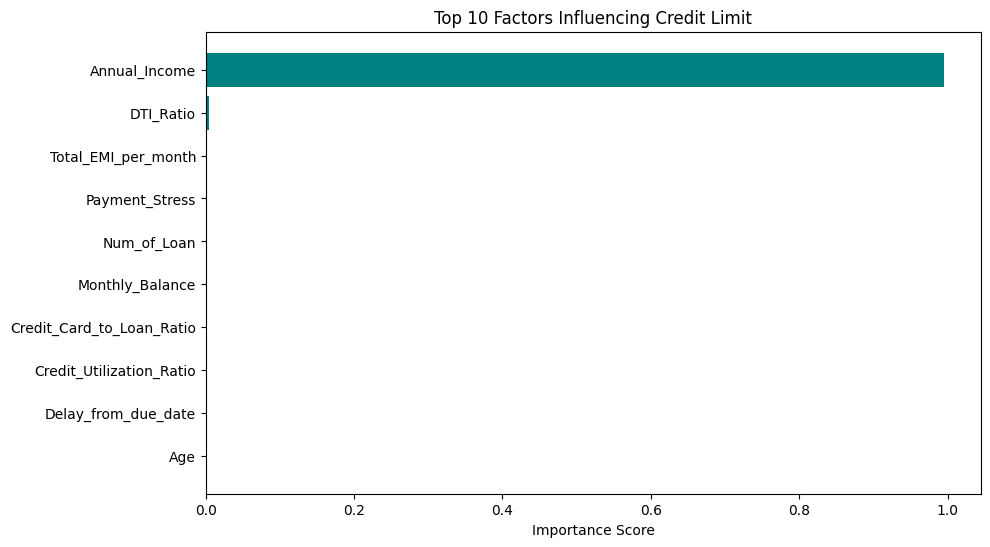

The Top 3 Drivers for the Credit Limit are: ['Annual_Income', 'DTI_Ratio', 'Total_EMI_per_month']


In [11]:
import pandas as pd
import numpy as np
import os
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestRegressor
import matplotlib.pyplot as plt

# 1. SETUP PATHS (Based on your tree structure)
# From notebooks/credit_risk/ we go up twice to reach E:/FP/
DATA_PATH = "../../data/raw/credit_risk_production_final.csv"
MODEL_DIR = "../../models/loan/"
os.makedirs(MODEL_DIR, exist_ok=True)

print("--- Step 1: Loading Data ---")
df = pd.read_csv(DATA_PATH)

# 2. TARGET ENGINEERING
# Approval Target
df['Is_Approved'] = df['Credit_Score'].apply(lambda x: 1 if x in [1, 2] else 0)

# Limit Target Logic
df['Monthly_Income'] = df['Annual_Income'] / 12
df['Suggested_Limit'] = (df['Monthly_Income'] * 0.40) - df['Total_EMI_per_month']
df['Suggested_Limit'] = df['Suggested_Limit'].clip(lower=500, upper=df['Monthly_Income'] * 3)

# 3. PREPARING FEATURES & SPLITTING
X = df.drop(columns=['Credit_Score', 'Is_Approved', 'Suggested_Limit', 'Monthly_Income'])

# Split for Approval
X_train_app, X_test_app, y_train_app, y_test_app = train_test_split(
    X, df['Is_Approved'], test_size=0.2, random_state=42, stratify=df['Is_Approved']
)

# Split for Limit (Only Approved customers)
X_approved = X[df['Is_Approved'] == 1]
y_limit = df.loc[df['Is_Approved'] == 1, 'Suggested_Limit']
X_train_lim, X_test_lim, y_train_lim, y_test_lim = train_test_split(
    X_approved, y_limit, test_size=0.2, random_state=42
)

print("--- Step 2: Training Champions ---")
# Approval Champion (Classification)
final_approval_model = HistGradientBoostingClassifier(random_state=42)
final_approval_model.fit(X_train_app, y_train_app)

# Limit Champion (Regression)
final_limit_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
final_limit_model.fit(X_train_lim, y_train_lim)

print("--- Step 3: Saving to .pkl format ---")
# Saving as .pkl in models/loan/
with open(os.path.join(MODEL_DIR, 'approval_model.pkl'), 'wb') as f:
    pickle.dump(final_approval_model, f)

with open(os.path.join(MODEL_DIR, 'credit_limit_model.pkl'), 'wb') as f:
    pickle.dump(final_limit_model, f)

with open(os.path.join(MODEL_DIR, 'feature_names.pkl'), 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print(f"✅ All files saved to {MODEL_DIR}")

# 4. VISUALIZATION (Interpretability)
importances = final_limit_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title('Top 10 Factors Influencing Credit Limit')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Importance Score')
plt.show()

# Final output for you to share
top_3 = [X.columns[i] for i in indices[-3:][::-1]]
print("The Top 3 Drivers for the Credit Limit are:", top_3)